## Maybe some code for better understanding Bayes Theorem?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Perceptron
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
rng = np.random.default_rng(42) # instance of numpy generator object

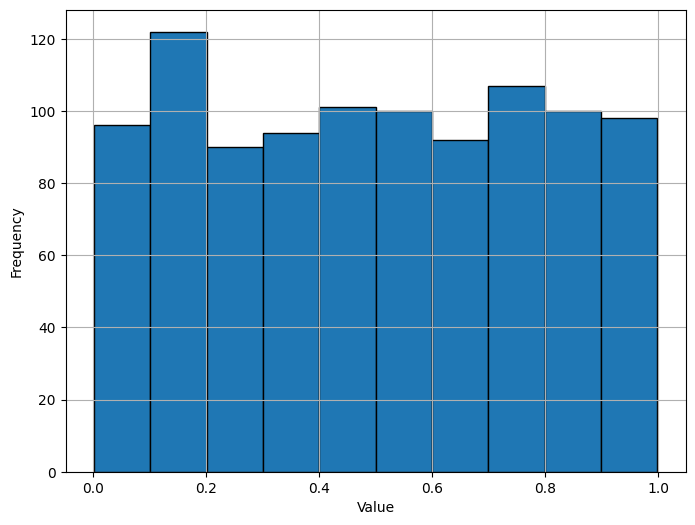

In [3]:
random_numbers = rng.random(1000) # uniform distribution

"""
rng.normal(loc=mean, scale=standard_deviation, size)
rng.uniform(low, high, size) or rng.random(size)
rng.exponential(scale=average_wait_time, size)
################## Discrete ##################
rng.binomial(n=number_of_trials, p=probability_of_success, size)
rng.poisson(lam=average_events_per_interval, size)
rng.integers(low, high, size)
"""

plt.figure(figsize=(8, 6))
plt.hist(random_numbers, bins=10, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Task 1 — Polynomial regression (underfitting vs. overfitting)
### Is there a higher risk of overfitting when there is fewer data points?
Build the data with NumPy: X = np.sort(rng.uniform(0, 2*np.pi, 15)), y = np.sin(X) + rng.normal(0, 0.2, X.shape). Fit LinearRegression on PolynomialFeatures of degree 2, 3, 5, and 9. Plot each fit against np.sin. Identify which degree underfits and which overfits.


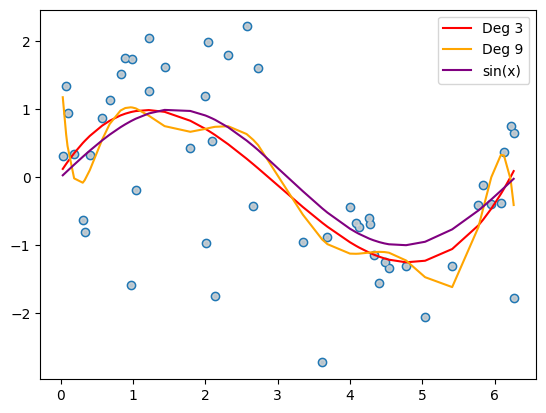

In [17]:
x = np.sort(rng.uniform(0, 2*np.pi, 50))
y = np.sin(x) + rng.normal(0, 1, x.shape)
plt.figure()
plt.scatter(x, y)

n_3 = PolynomialFeatures(degree=3)
n_9 = PolynomialFeatures(degree=9)



plt.scatter(x, y, color='lightgray',alpha=0.85, s=15)


# 2. Reshape x for scikit-learn
X = x.reshape(-1, 1)
model = LinearRegression()



X_3 = n_3.fit_transform(X)
model.fit(X_3, y)
plt.plot(x, model.predict(X_3), label='Deg 3', color='red')
X_9 = n_9.fit_transform(X)
model.fit(X_9, y)
plt.plot(x, model.predict(X_9), label='Deg 9', color='orange')

plt.plot(x, np.sin(x), label='sin(x)', color='purple')
plt.legend()

plt.show()

## Perceptron and the XOR problem
Linearly separable set: two Gaussian clusters via rng.normal, e.g. centers at [-2,-2] and [2,2]. Train Perceptron, report accuracy. Then the XOR set: X = np.array([[0,0],[0,1],[1,0],[1,1]]), y = np.array([0,1,1,0]). Show it cannot classify XOR correctly.


Gaussian clusters accuracy: 0.795


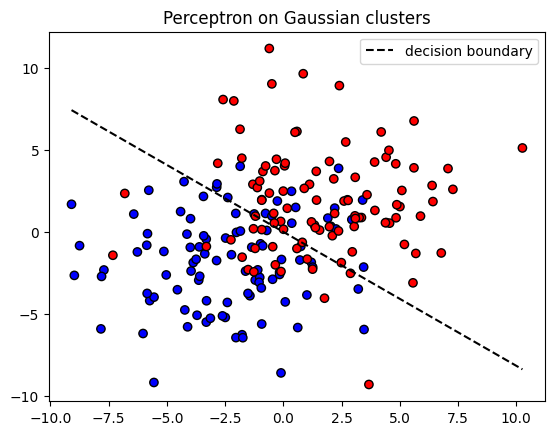

[4.15079636 5.0785513 ]


In [5]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(0)

# 1. Linearly separable: two Gaussian clusters
n = 100
c0 = rng.normal([-2, -2], 3, size=(n, 2))
c1 = rng.normal([2, 2], 3, size=(n, 2))
X = np.vstack([c0, c1])
y = np.array([0] * n + [1] * n)

clf = Perceptron()
clf.fit(X, y)
print("Gaussian clusters accuracy:", accuracy_score(y, clf.predict(X)))


w = clf.coef_[0]
b = clf.intercept_[0]
xs = np.array([X[:, 0].min(), X[:, 0].max()])
ys = -(w[0] * xs + b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k")
plt.plot(xs, ys, "k--", label="decision boundary")
plt.legend()
plt.title("Perceptron on Gaussian clusters")
plt.show()
print(w)


In [6]:
# 2. XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

clf_xor = Perceptron()
clf_xor.fit(X_xor, y_xor)
print("XOR accuracy:", accuracy_score(y_xor, clf_xor.predict(X_xor)))
print("XOR predictions:", clf_xor.predict(X_xor), "true:", y_xor)


XOR accuracy: 0.5
XOR predictions: [0 0 0 0] true: [0 1 1 0]


## One-hot encoding (encodes labels as matrix)
Create labels with NumPy: labels = rng.choice(["house","car","cat","flower"], size=5).reshape(-1,1). Transform with OneHotEncoder and display the vectors.


In [7]:
# rng = np.random.default_rng => Generater instance for all sorts of random stuff
labels = rng.choice(["house","car","cat","flower"], size=5).reshape(-1,1) # .choice samples from a list of elements (str, int etc.)
print(labels)

[['car']
 ['house']
 ['flower']
 ['cat']
 ['flower']]


In [8]:
ohe = OneHotEncoder(sparse_output=False)
ohe.fit_transform(labels)

array([[1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

## Least squares classification and outlier sensitivity
Two NumPy Gaussian clusters (labels 0/1). One-hot encode the labels and fit LinearRegression to obtain a decision boundary. Append a few far outliers with np.vstack, refit, and show the boundary shifts.


## Support Vector Machine
Same clusters as Task 7, with and without the outliers. Fit SVC(kernel="linear"). Plot the boundary, margins, and support vectors. Confirm the boundary is unaffected by outliers, unlike Task 7.

In [9]:
np.random.seed(42)
c1 = np.random.multivariate_normal([2, 2, 2], np.eye(3) *15, 250)
c2 = np.random.multivariate_normal([5, 5, 5], np.eye(3) *15, 250)

X = np.vstack((c1, c2))
y = np.array([0] * 250 + [1] * 250)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
clf = SVC(kernel="linear")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.74


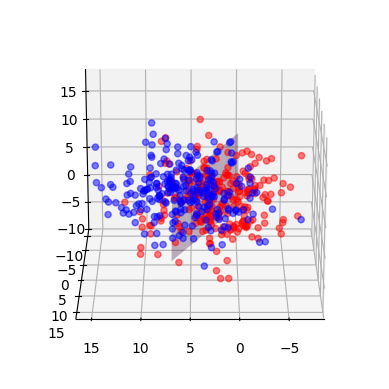

In [11]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(X[y == 0, 0], X[y == 0, 1], X[y == 0, 2], color="r", alpha=0.5)
ax.scatter(X[y == 1, 0], X[y == 1, 1], X[y == 1, 2], color="b", alpha=0.5)

xx, yy = np.meshgrid(np.linspace(0, 7, 10), np.linspace(0, 7, 10))
w = clf.coef_[0]
zz = (-w[0] * xx - w[1] * yy - clf.intercept_[0]) / w[2]
ax.plot_surface(xx, yy, zz, alpha=0.3, color="purple")

ax.view_init(elev=20, azim=90)
plt.show()

In [12]:
ax.view_init(elev=20, azim=135)
plt.show()

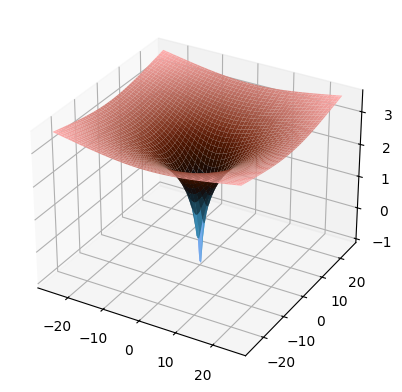

In [13]:
x = np.linspace(-25, 25, 100)
y = np.linspace(-25, 25, 100)
X, Y = np.meshgrid(x, y)
#Z = np.sin(np.sqrt(X**2 + Y**2))
Z = np.log(np.sqrt(X**2 + Y**2))
fig = plt.figure()
ax = plt.axes(projection='3d')

surface = ax.plot_surface(X, Y, Z, cmap='berlin')
plt.show()

# **Multilayer Perceptron**

Implements a feedforward neural network (a multilayer perceptron) trained with backpropagation.
----
**Arguments:**
* hidden_layer_sizes=(a, b, c)  *#a, b, c are the amount of neurons in a layer*
* activation    *#activation function for every layer*
* solver
* batch_size
* max_iter
* alpha   *#Strength of the L2 regularization term, default=0.0001*
* random_state    *#init for weights & biases, for reproducibility*

In [14]:
from sklearn.neural_network import MLPClassifier
X = [[0., 0.], [1., 1.]]
y = [0, 1]
clf = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(5, 2), random_state=1, alpha = 0.05)
clf.fit(X, y)
clf.predict([[0, 0], [1, 1]])
accuracy_score = clf.score(X, y)
print(accuracy_score)

1.0


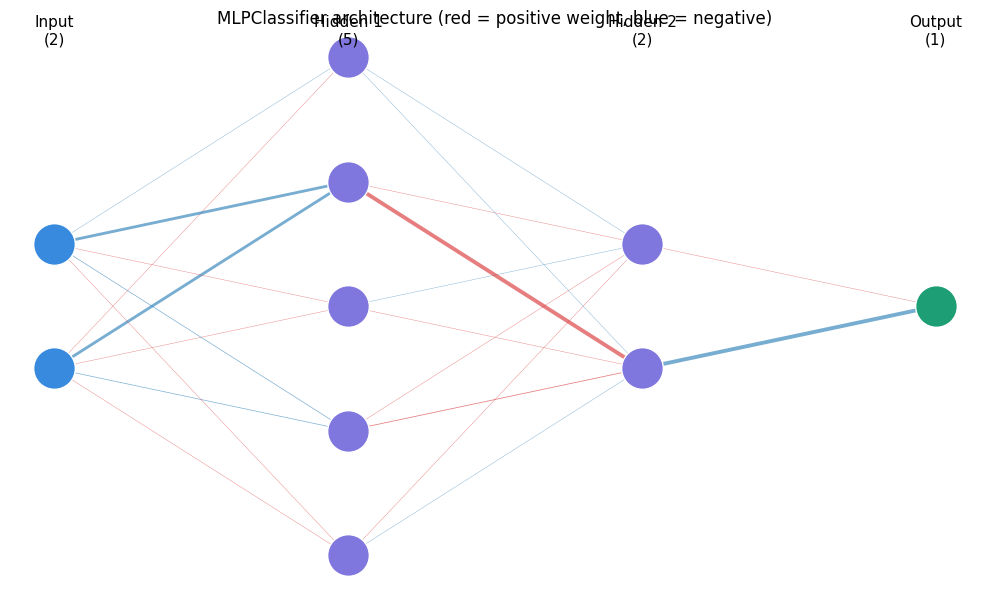

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def draw_mlp(clf, feature_names=None):
    layer_sizes = [clf.coefs_[0].shape[0]] + [c.shape[1] for c in clf.coefs_]
    n_layers = len(layer_sizes)
    v_spacing = 1.0
    h_spacing = 3.0

    coords = []
    for i, size in enumerate(layer_sizes):
        ys = np.linspace(-(size - 1) / 2, (size - 1) / 2, size) * v_spacing
        coords.append([(i * h_spacing, y) for y in ys])

    fig, ax = plt.subplots(figsize=(10, 6))

    max_w = max(np.abs(c).max() for c in clf.coefs_)
    for li, W in enumerate(clf.coefs_):
        for a, (x0, y0) in enumerate(coords[li]):
            for b, (x1, y1) in enumerate(coords[li + 1]):
                w = W[a, b]
                color = 'tab:red' if w > 0 else 'tab:blue'
                ax.plot([x0, x1], [y0, y1], color=color,
                        linewidth=0.3 + 2.5 * abs(w) / max_w, alpha=0.6)

    palette = ['#378ADD', '#7F77DD', '#7F77DD', '#1D9E75']
    labels = ['Input'] + [f'Hidden {i+1}' for i in range(n_layers - 2)] + ['Output']
    for i, layer in enumerate(coords):
        for (x, y) in layer:
            ax.scatter(x, y, s=900, color=palette[i % len(palette)], zorder=3, edgecolors='white')
        ax.text(i * h_spacing, max(p[1] for p in coords[0]) + 1.6,
                f'{labels[i]}\n({layer_sizes[i]})', ha='center', fontsize=11)

    ax.axis('off')
    ax.set_title('MLPClassifier architecture (red = positive weight, blue = negative)')
    plt.tight_layout()
    plt.show()

draw_mlp(clf)